# Módulo 4: IA Generativa aplicada a Operaciones
### LLMs, Embeddings, RAG y Copilotos
**Workshop: IA aplicada a Distribución de Energía**

## Agenda (~2 horas)

| Bloque | Tema | Duración |
|--------|------|----------|
| 1 | LLMs: qué son y cómo funcionan | 20 min |
| 2 | Embeddings y búsqueda semántica | 20 min |
| 3 | RAG: conectar IA con documentos de EPEC | 30 min |
| 4 | Copilotos: SQL, Python e incidentes | 25 min |
| 5 | Datos sintéticos y riesgos de GenAI | 15 min |
| 6 | Cierre: diseño de piloto y recursos | 10 min |

## Repaso de Módulos 1-3

Hasta ahora vimos:

| Módulo | Qué aprendimos | Tipo |
|--------|---------------|------|
| 1 | Regresión, Feature Engineering | Supervisado |
| 2 | Clasificación, K-Means, PCA, CRISP-DM | Supervisado + No supervisado |
| 3 | Ensembles, Deep Learning, RL | Modelos avanzados |
| **4** | **LLMs, RAG, Copilotos** | **IA Generativa** |

**Cambio de paradigma:** En los módulos anteriores, entrenamos modelos con datos numéricos.  
Hoy trabajamos con **texto** y modelos que ya fueron pre-entrenados por otros (Google, OpenAI, Meta).

In [1]:
# Instalar librerias necesarias (puede tardar 1-2 minutos)
!pip install -q sentence-transformers chromadb

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
print('Librerias listas!')

Librerias listas!


---
## Bloque 1: LLMs - Large Language Models

### ¿Qué es un LLM?

Un **Large Language Model** es una red neuronal gigante entrenada con texto de internet.
En esencia, es un modelo que **predice la siguiente palabra**.

![LLM](https://www.wwwinsights.com/wp-content/uploads/2025/10/image-1-1024x408.png)

| Concepto | Descripción |
|----------|-------------|
| LLM | Una red neuronal masiva — pensalo como un empleado nuevo que leyó TODA la documentación |
| Prompt | La instrucción o pregunta que le damos al modelo |
| Token | Las "piezas" en que se divide el texto para procesarlo |
| Contexto | Cuánta información puede tener en cuenta a la vez |

**Importante:** Los LLMs NO piensan, NO razonan, NO buscan en internet.
Solo predicen texto basándose en patrones estadísticos.

### IA Generativa: no es solo texto

Cuando hablamos de IA Generativa solemos pensar en ChatGPT, pero la generación de contenido va más allá del texto:

| Modalidad | Qué genera | Ejemplo en distribución de energía |
|-----------|-----------|-----------------------------------|
| **Texto** | Texto, código, respuestas | Clasificar reclamos, generar consultas SQL, resumir documentos |
| **Imagen** | Fotos, ilustraciones, diagramas | Generar imágenes sintéticas de fallas en equipos para entrenar modelos de inspección visual |
| **Audio** | Voz, sonidos | Generar alertas de voz automáticas para operadores del centro de control |
| **Video** | Clips, animaciones | Generar simulaciones visuales de escenarios de falla para capacitación |

Además, los modelos generativos actuales son **multimodales**: no solo generan contenido, sino que también pueden **analizar** imágenes, audio y video. Esto habilita casos como:

| Capacidad | Ejemplo |
|-----------|---------|
| Analizar una imagen | Un inspector saca foto de un transformador y el modelo identifica el tipo de falla |
| Analizar audio | Detectar patrones anormales en el sonido de un transformador (zumbido irregular) |
| Imagen + texto | Enviar foto de un equipo dañado y preguntar: "¿qué falla tiene y cuál es el procedimiento?" |

> En este módulo nos enfocamos en **texto (LLMs)** porque es la modalidad más madura y aplicable hoy.
> Pero vale saber que modelos como GPT-4o, Gemini y Claude ya son multimodales.

### 1.1 Tokenización: cómo lee texto una IA

Nosotros leemos **palabras**. Un LLM lee **tokens** (pedazos de palabras).
La forma en que el modelo representa el texto internamente afecta directamente su costo, velocidad y capacidad.

In [3]:
# Simulacion simple de tokenizacion
# (Los LLMs reales usan BPE - Byte Pair Encoding, mucho mas sofisticado)

texto = "El transformador de la subestacion norte tiene sobrecarga"

# Tokenizacion por palabras (simplificada)
tokens_simple = texto.split()
print(f"Texto original: '{texto}'")
print(f"Tokens (simple): {tokens_simple}")
print(f"Cantidad de tokens: {len(tokens_simple)}")
print()

# En realidad, un LLM tokeniza diferente:
# "transformador" -> ["transform", "ador"]
# "subestacion"  -> ["sub", "estacion"]
# Esto permite manejar palabras nuevas que nunca vio

tokens_subword = ["El", "transform", "ador", "de", "la", "sub", "estacion", 
                  "norte", "tiene", "sobre", "carga"]
print(f"Tokens (subword): {tokens_subword}")
print(f"Cantidad de tokens: {len(tokens_subword)}")
print()
print("Cada token se convierte en un numero (ID) que el modelo puede procesar")
token_ids = {t: i+1000 for i, t in enumerate(tokens_subword)}
print(f"Token IDs: {token_ids}")

Texto original: 'El transformador de la subestacion norte tiene sobrecarga'
Tokens (simple): ['El', 'transformador', 'de', 'la', 'subestacion', 'norte', 'tiene', 'sobrecarga']
Cantidad de tokens: 8

Tokens (subword): ['El', 'transform', 'ador', 'de', 'la', 'sub', 'estacion', 'norte', 'tiene', 'sobre', 'carga']
Cantidad de tokens: 11

Cada token se convierte en un numero (ID) que el modelo puede procesar
Token IDs: {'El': 1000, 'transform': 1001, 'ador': 1002, 'de': 1003, 'la': 1004, 'sub': 1005, 'estacion': 1006, 'norte': 1007, 'tiene': 1008, 'sobre': 1009, 'carga': 1010}


### ¿Por qué importa la tokenización?

- **Costo:** Los LLMs cobran por token (no por palabra). Más tokens = más caro.
- **Límite de contexto:** Cada modelo tiene un máximo de tokens que puede procesar a la vez.
- **Idioma:** El español usa ~30% más tokens que el inglés para decir lo mismo.

| Modelo | Tipo | Tokens de contexto | Equivale a... |
|--------|------|--------------------|---------------|
| GPT-3.5 | Propietario (OpenAI) | 4,096 | ~3 páginas |
| GPT-4o | Propietario (OpenAI) | 128,000 | ~100 páginas |
| Claude 3.5 | Propietario (Anthropic) | 200,000 | ~150 páginas |
| Gemini 1.5 | Propietario (Google) | 1,000,000 | ~750 páginas |
| Llama 3.1 | **Open source** (Meta) | 128,000 | ~100 páginas |
| Qwen 2.5 | **Open source** (Alibaba) | 128,000 | ~100 páginas |
| DeepSeek V3 | **Open source** (DeepSeek) | 128,000 | ~100 páginas |

> **Dato clave:** Los modelos open source ya igualan a los propietarios en ventana de contexto
> (128K tokens). La diferencia principal hoy está en la calidad de las respuestas, no en cuánto
> texto pueden procesar. Además, los modelos open source se pueden correr localmente
> (sin enviar datos a terceros), lo cual es importante para datos sensibles.

### 1.2 Parámetros y Temperatura

#### Parámetros: el tamaño del modelo

Los **parámetros** son los pesos internos de la red neuronal — los números que el modelo ajustó durante su entrenamiento. Cuantos más parámetros, más patrones y conocimiento puede almacenar el modelo, pero también más recursos necesita para funcionar.

| Modelo | Parámetros | Tamaño aproximado |
|--------|-----------|-------------------|
| Llama 3.2 | 3B (3 mil millones) | ~2 GB — corre en una notebook |
| Mistral | 7B | ~4 GB — necesita buena GPU |
| Llama 3.1 | 70B | ~40 GB — necesita un servidor |
| GPT-4 (estimado) | ~1.8T (1.8 billones) | Solo disponible vía API |

Los parámetros vienen fijos: se definen durante el entrenamiento del modelo y no se modifican cuando lo usamos. Elegir un modelo más grande no siempre es mejor — depende de la tarea y de los recursos disponibles.

#### Temperatura: la creatividad de la respuesta

La **temperatura** sí es algo que controlamos nosotros al usar el modelo. Regula cuánto se "arriesga" al elegir la siguiente palabra:

| Temperatura | Comportamiento | Uso |
|-------------|---------------|-----|
| 0.0 | Siempre la misma respuesta (determinista) | Clasificación, extracción de datos |
| 0.3-0.5 | Algo de variación | Resumen de documentos |
| 0.7-1.0 | Creativo, variado | Generación de ideas, redacción |

> **Regla práctica:** Para tareas operativas (extraer datos, clasificar reclamos),
> usen temperatura **baja** (0.0-0.3). Para generar reportes o emails, temperatura **media** (0.5).

Prompt: 'El transformador fallo por...'

Probabilidades originales del modelo (antes de aplicar temperatura): {'sobrecarga': 0.4, 'cortocircuito': 0.25, 'envejecimiento': 0.2, 'vandalismo': 0.1, 'terremoto': 0.05}

--- Temperatura = 0.0 (determinista) ---
El modelo SIEMPRE elige 'sobrecarga' (100% probabilidad)
Las demas opciones quedan en 0%. No hay azar.

--- Temperatura = 1.0 (creativo) ---
Se mantienen las probabilidades originales.
Podria elegir cualquiera, con mas chance las mas probables.


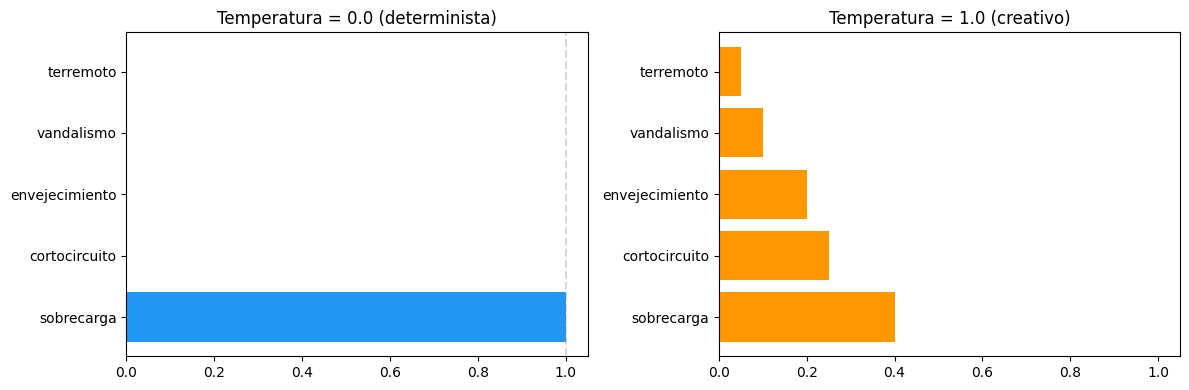

In [4]:
# Simulacion de temperatura con un ejemplo simple
# Imaginemos que el modelo tiene que completar: "El transformador fallo por..."

opciones = {
    "sobrecarga": 0.40,
    "cortocircuito": 0.25,
    "envejecimiento": 0.20,
    "vandalismo": 0.10,
    "terremoto": 0.05
}

print("Prompt: 'El transformador fallo por...'")
print(f"\nProbabilidades originales del modelo (antes de aplicar temperatura): {opciones}")

print("\n--- Temperatura = 0.0 (determinista) ---")
print("El modelo SIEMPRE elige 'sobrecarga' (100% probabilidad)")
print("Las demas opciones quedan en 0%. No hay azar.")

print("\n--- Temperatura = 1.0 (creativo) ---")
print("Se mantienen las probabilidades originales.")
print("Podria elegir cualquiera, con mas chance las mas probables.")

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Temp = 0: TODA la probabilidad va al mas probable
probs_baja = np.array([1.00, 0.00, 0.00, 0.00, 0.00])
colors_baja = ['#2196F3', '#BBDEFB', '#BBDEFB', '#BBDEFB', '#BBDEFB']
axes[0].barh(list(opciones.keys()), probs_baja, color=colors_baja)
axes[0].set_title('Temperatura = 0.0 (determinista)')
axes[0].set_xlim(0, 1.05)
axes[0].axvline(x=1.0, color='gray', linestyle='--', alpha=0.3)

# Temp = 1: se mantienen las probabilidades originales
probs_alta = np.array(list(opciones.values()))
axes[1].barh(list(opciones.keys()), probs_alta, color='#FF9800')
axes[1].set_title('Temperatura = 1.0 (creativo)')
axes[1].set_xlim(0, 1.05)

plt.tight_layout()
plt.show()

> **¿Qué nos dice este gráfico?** A la izquierda, con temperatura 0.0, el modelo asigna el 100% de la probabilidad a "sobrecarga" (la opción más probable) y 0% a todas las demás. Es completamente determinista: siempre va a dar la misma respuesta. A la derecha, con temperatura 1.0, se mantienen las probabilidades originales del modelo y hay chance de que elija cualquier opción (aunque las más probables siguen teniendo más peso). Temperaturas intermedias (0.3-0.7) concentran la probabilidad en las opciones más probables pero sin eliminar completamente a las demás.

### Para seguir explorando: LLMs

Ejercicios para explorar en casa. No hace falta entregar nada — son para que experimenten y entiendan mejor cómo funcionan los LLMs.

**1. Probar tokenización en la práctica:**
Ir a [platform.openai.com/tokenizer](https://platform.openai.com/tokenizer) y probar cómo se tokenizan distintas frases en español vs inglés. ¿Cuántos tokens más usa el español?

**2. Experimentar con temperatura:**
Si tienen acceso a ChatGPT, Google AI Studio u otro LLM, probar la misma pregunta técnica con temperatura 0 y temperatura 1. ¿Qué diferencias notan en las respuestas? (Google AI studio: https://aistudio.google.com/prompts/new_chat)

**3. Reflexionar:**
Pensando en su trabajo diario: ¿en qué tareas les convendría una respuesta siempre igual (temperatura baja) y en cuáles una respuesta más variada (temperatura alta)?

---
## Bloque 2: Embeddings y Búsqueda Semántica

### ¿Qué es un Embedding?

Un **embedding** convierte texto en un **vector numérico** (una lista de números).
Textos con significado similar tendrán vectores cercanos en ese espacio.

![Embedding](https://glasswing.vc/wp-content/uploads/2023/10/8-Embeddings-.webp)

| Búsqueda por texto exacto | Búsqueda semántica (Embeddings) |
|---------------------------|--------------------------------|
| Busca coincidencias exactas de palabras | Busca por significado |
| Solo encuentra lo que escribiste literalmente | Encuentra textos con sentido similar |
| Rápido pero limitado | Más inteligente |

In [5]:
# Cargar un modelo de embeddings MULTILINGUE (descarga ~470MB la primera vez)
# Usamos un modelo multilingue porque nuestros textos estan en espanol
from sentence_transformers import SentenceTransformer

modelo_emb = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
print('Modelo de embeddings cargado!')
print(f'Modelo: paraphrase-multilingual-MiniLM-L12-v2')
print(f'Dimension de los vectores: {modelo_emb.get_sentence_embedding_dimension()}')
print(f'\nNota: usamos un modelo multilingue para que capture bien')
print(f'el significado de textos en espanol.')

/Users/farduh/xcapit/Capacitaci-nIA/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6880.56it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo de embeddings cargado!
Modelo: paraphrase-multilingual-MiniLM-L12-v2
Dimension de los vectores: 384

Nota: usamos un modelo multilingue para que capture bien
el significado de textos en espanol.


In [6]:
# Ejemplo: convertir textos de EPEC en embeddings
textos_epec = [
    "Se corto la luz en barrio norte",
    "No tengo suministro electrico en mi domicilio",
    "Quiero pagar la factura de este mes",
    "El transformador de la esquina esta haciendo ruido",
    "Hubo un apagon en toda la cuadra",
    "Necesito cambiar la titularidad del medidor",
    "El cable de la calle esta caido y es peligroso",
    "Quiero consultar mi deuda"
]

# Generar embeddings
embeddings = modelo_emb.encode(textos_epec)

print(f"Cantidad de textos: {len(textos_epec)}")
print(f"Dimension de cada embedding: {embeddings.shape[1]}")
print(f"\nEjemplo - primeros 10 valores del embedding de '{textos_epec[0]}':")
print(np.round(embeddings[0][:10], 4))

Cantidad de textos: 8
Dimension de cada embedding: 384

Ejemplo - primeros 10 valores del embedding de 'Se corto la luz en barrio norte':
[ 0.1984 -0.0727  0.3026  0.3059  0.3666 -0.0429 -0.1098 -0.2733 -0.1418
  0.006 ]


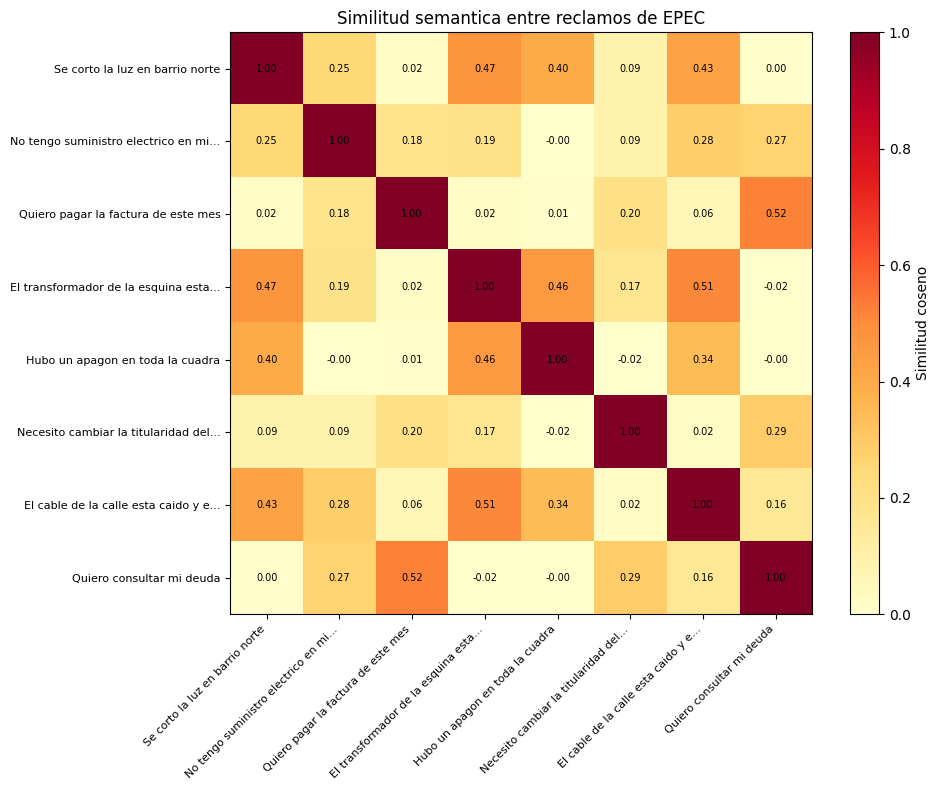

In [7]:
# Similitud coseno: mide cuanto se parecen dos vectores (0=nada, 1=identicos)
from sklearn.metrics.pairwise import cosine_similarity

similitudes = cosine_similarity(embeddings)

# Heatmap de similitudes
fig, ax = plt.subplots(figsize=(10, 8))

# Etiquetas cortas
etiquetas = [t[:35] + '...' if len(t) > 35 else t for t in textos_epec]

im = ax.imshow(similitudes, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(len(etiquetas)))
ax.set_yticks(range(len(etiquetas)))
ax.set_xticklabels(etiquetas, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(etiquetas, fontsize=8)

# Agregar valores en las celdas
for i in range(len(textos_epec)):
    for j in range(len(textos_epec)):
        ax.text(j, i, f'{similitudes[i,j]:.2f}', ha='center', va='center', fontsize=7)

plt.colorbar(im, label='Similitud coseno')
plt.title('Similitud semantica entre reclamos de EPEC')
plt.tight_layout()
plt.show()

> **¿Qué nos dice este gráfico?** La diagonal siempre vale 1.0 (cada texto es idéntico a sí mismo). Lo interesante son los valores fuera de la diagonal:
> - **"No tengo suministro eléctrico"** debería tener alta similitud con textos sobre cortes de luz — comparten el campo semántico de "falta de energía".
> - **"Quiero pagar la factura"** y **"Quiero consultar mi deuda"** — ambos son temas comerciales, ¿se refleja?
> - Noten si hay pares que esperarían que sean similares pero el modelo no los conecta. Por ejemplo, **"Hubo un apagón"** debería estar cerca de **"Se cortó la luz"**, pero no siempre lo está.
>
> Los embeddings capturan significado, pero no son perfectos. Dependen de con qué datos fue entrenado
> el modelo. Si un sinónimo no apareció suficiente en los datos de entrenamiento, el modelo no lo
> va a conectar. Esta es una de las razones por las que en producción se agrega **expansión de queries**
> (como vamos a ver más adelante).

In [8]:
# Busqueda semantica: encontrar reclamos similares a una consulta
consulta = "no tengo electricidad"

# Convertir consulta a embedding
emb_consulta = modelo_emb.encode([consulta])

# Calcular similitud con todos los textos
similitudes_consulta = cosine_similarity(emb_consulta, embeddings)[0]

# Ordenar por similitud
ranking = np.argsort(similitudes_consulta)[::-1]

print(f"Consulta: '{consulta}'")
print(f"\nResultados ordenados por similitud semantica:")
print("=" * 60)
for i, idx in enumerate(ranking):
    barra = '█' * int(similitudes_consulta[idx] * 30)
    print(f"{i+1}. [{similitudes_consulta[idx]:.3f}] {barra} {textos_epec[idx]}")

Consulta: 'no tengo electricidad'

Resultados ordenados por similitud semantica:
1. [0.881] ██████████████████████████ No tengo suministro electrico en mi domicilio
2. [0.288] ████████ El cable de la calle esta caido y es peligroso
3. [0.255] ███████ Se corto la luz en barrio norte
4. [0.226] ██████ El transformador de la esquina esta haciendo ruido
5. [0.222] ██████ Quiero consultar mi deuda
6. [0.103] ███ Quiero pagar la factura de este mes
7. [0.064] █ Hubo un apagon en toda la cuadra
8. [0.051] █ Necesito cambiar la titularidad del medidor


> **Lectura de resultados:** El resultado más similar es "No tengo suministro eléctrico" con una similitud muy alta — tiene sentido porque comparte estructura ("no tengo...") y campo semántico ("eléctrico"/"electricidad"). Pero noten que **"Hubo un apagón en toda la cuadra"** aparece muy abajo en el ranking, a pesar de que semánticamente está relacionado. El modelo no conecta "electricidad" con "apagón" tan bien como esperaríamos.
>
> Esto muestra una limitación real de los embeddings: **no son omniscientes**. Capturan muchas relaciones semánticas, pero no todas. Es por eso que en sistemas de producción se complementan con otras técnicas como la expansión de queries (mapear "apagón" → "corte de suministro eléctrico") o la búsqueda híbrida (combinar semántica con búsqueda por palabras clave).

### Ventaja sobre SQL LIKE

```sql
-- Búsqueda clásica: pierde resultados relevantes
SELECT * FROM reclamos WHERE texto LIKE '%electricidad%'
-- Solo encuentra textos que contengan la palabra exacta "electricidad"

-- Con embeddings, "no tengo electricidad" también encuentra:
-- "Se corto la luz" (no contiene "electricidad"!)
-- "No tengo suministro eléctrico" 
-- "Hubo un apagon"
```

### Para seguir explorando: Embeddings

**1. Agregar reclamos nuevos:**
Agreguen 3-4 reclamos más a la lista `textos_epec` y vuelvan a generar el heatmap. ¿Se agrupan donde esperaban?

**2. Probar consultas ambiguas:**
¿Qué pasa si buscan algo ambiguo como "tengo un problema"? ¿Y si buscan algo que no tiene nada que ver, como "quiero reservar un vuelo"? ¿Qué similitudes les da?

**3. Pensar casos de uso:**
¿En qué otros contextos de su trabajo sería útil buscar por significado en vez de por texto exacto? Por ejemplo: búsqueda en correos, en documentación técnica, en tickets de soporte...

---
## Bloque 3: RAG - Retrieval Augmented Generation

### El problema fundamental de los LLMs

Los LLMs saben mucho del mundo... pero **NO conocen los documentos internos de tu organización**.
Si le preguntás a ChatGPT: *"¿Cuál es el procedimiento para reconectar un transformador?"*
Te va a inventar algo genérico (alucinación).

### La solución: RAG

**RAG = Retrieval Augmented Generation** (Generación Aumentada por Recuperación)

Pensalo así:
- **Sin RAG:** le preguntás algo a un empleado nuevo sin darle el manual
- **Con RAG:** le dás las páginas relevantes del manual y DESPUÉS le preguntás

![RAG](https://developer-blogs.nvidia.com/wp-content/uploads/2023/12/rag-pipeline-ingest-query-flow-b.png)

**Flujo RAG:**
1. El usuario hace una pregunta
2. El sistema busca documentos relevantes (embeddings)
3. Se arma un prompt con la pregunta + los documentos encontrados
4. El LLM responde basándose en esos documentos

In [ ]:
# Paso 1: Crear una base de conocimiento de EPEC (simulada)
# En produccion, estos serian PDFs/Word/paginas web reales de EPEC

documentos_epec = [
    {
        "id": "PROC-001",
        "titulo": "Reconexion de transformador de distribucion",
        "contenido": """Procedimiento para reconectar un transformador de distribucion despues de una falla:
1. Verificar que la causa de la desconexion fue identificada y resuelta.
2. Inspeccionar visualmente el transformador buscando danos externos, fugas de aceite o marcas de arco electrico.
3. Medir resistencia de aislamiento con megohmetro. Valor minimo aceptable: 1 Megaohm por kV de tension nominal.
4. Verificar nivel de aceite en el tanque. Debe estar entre las marcas MIN y MAX del visor.
5. Cerrar seccionador de alta tension.
6. Energizar el transformador sin carga durante 15 minutos.
7. Medir tensiones de salida en vacio. Deben estar dentro del +/- 5% de la tension nominal.
8. Cerrar interruptor de baja tension y reconectar cargas gradualmente.
9. Monitorear temperatura y corrientes durante las primeras 2 horas."""
    },
    {
        "id": "PROC-002",
        "titulo": "Protocolo de seguridad para trabajos en lineas de media tension",
        "contenido": """Protocolo obligatorio para todo trabajo en lineas de media tension (13.2 kV / 33 kV):
1. Obtener autorizacion del Centro de Control de Operaciones (CCO).
2. Verificar apertura del seccionador correspondiente con el CCO.
3. Comprobar ausencia de tension con detector apropiado para el nivel de tension.
4. Instalar puesta a tierra y en cortocircuito en ambos extremos del tramo.
5. Delimitar zona de trabajo con cinta y senalizacion.
6. Todo el personal debe usar EPP completo: casco, guantes dieléctricos, calzado aislante.
7. Mantener distancias minimas de seguridad: 0.9m para 13.2kV, 1.5m para 33kV.
8. Al finalizar, retirar elementos en orden inverso. Ultimo paso: retirar puesta a tierra."""
    },
    {
        "id": "PROC-003",
        "titulo": "Gestion de reclamos por corte de suministro",
        "contenido": """Proceso para gestionar reclamos de clientes por corte de suministro:
1. Registrar reclamo en sistema SIGRE con datos del cliente (NIS, direccion, telefono).
2. Clasificar el reclamo: individual (afecta un medidor) o masivo (afecta zona/alimentador).
3. Si es individual: verificar estado de cuenta. Si hay deuda > 2 meses, derivar a Comercial.
4. Si es masivo: verificar en SCADA si hay alarmas en el alimentador correspondiente.
5. Generar orden de trabajo para cuadrilla de emergencia.
6. Tiempo maximo de respuesta: 4 horas para zona urbana, 8 horas para zona rural.
7. Informar al cliente el tiempo estimado de restitucion.
8. Una vez resuelto, cerrar el reclamo en SIGRE con detalle de la causa y solucion."""
    },
    {
        "id": "PROC-004",
        "titulo": "Mantenimiento preventivo de transformadores",
        "contenido": """Plan de mantenimiento preventivo para transformadores de distribucion:
Frecuencia semestral:
- Inspeccion visual externa (fugas, oxidacion, estado de bornes).
- Medicion de temperatura de operacion con camara termografica.
- Verificar ajuste de conexiones (par de apriete segun fabricante).
- Limpieza de aisladores y bushings.
Frecuencia anual:
- Analisis fisico-quimico de aceite (rigidez dielectrica, humedad, acidez, gases disueltos).
- Medicion de resistencia de aislamiento.
- Verificacion de protecciones (fusibles, rele de sobrecorriente).
- Actualizar ficha tecnica en sistema GIS.
Criterio de reemplazo: si el aceite muestra gases combustibles > 500 ppm o rigidez < 30 kV."""
    },
    {
        "id": "PROC-005",
        "titulo": "Deteccion de fraude o hurto de energia",
        "contenido": """Procedimiento para detectar y gestionar fraude de energia:
Indicadores de posible fraude:
- Consumo registrado cae abruptamente mas de 50% sin motivo aparente.
- Diferencia entre energia entregada al transformador y suma de medidores > 15%.
- Reclamos de vecinos sobre conexiones irregulares.
- Medidor con precintos violados o vidrio empanado.
Acciones:
1. Generar caso en sistema antifraude con evidencia.
2. Programar inspeccion de cuadrilla especializada.
3. Documentar con fotos y acta notarial si se confirma fraude.
4. Calcular energia no facturada (ultimos 12 meses de diferencia).
5. Generar cargo retroactivo y derivar a Legal si corresponde."""
    },
    {
        "id": "PROC-006",
        "titulo": "Procedimiento ante tormentas y emergencias climaticas",
        "contenido": """Protocolo de actuacion ante alertas meteorologicas:
Nivel AMARILLO (vientos > 60 km/h o lluvia intensa):
- Activar guardia reforzada en CCO.
- Pre-posicionar cuadrillas en zonas historicamente afectadas.
- Verificar stock de materiales criticos (fusibles, cable, conectores).
Nivel NARANJA (vientos > 90 km/h o granizo):
- Activar todas las cuadrillas disponibles.
- Abrir centro de atencion de emergencias.
- Informar a medios sobre posibles cortes.
Nivel ROJO (vientos > 120 km/h, tornado):
- Priorizar seguridad del personal sobre restitucion.
- Coordinar con Defensa Civil y Bomberos.
- Activar protocolo de comunicacion masiva a clientes.
Priorizacion de restitucion: hospitales > bomberos > clientes vulnerables > zonas urbanas > rural."""
    },
    {
        "id": "PROC-007",
        "titulo": "Lectura y facturacion de medidores",
        "contenido": """Proceso mensual de lectura y facturacion:
1. Generar rutas de lectura agrupadas por zona y lector.
2. Descargar rutas a terminales portatiles (TPL).
3. El lector registra lectura del medidor. Si no puede acceder, registra codigo de impedimento.
4. Validaciones automaticas del sistema:
   - Consumo negativo: posible error de lectura o cambio de medidor.
   - Consumo > 3x promedio historico: posible error, requiere re-lectura.
   - Consumo = 0 por 2 meses consecutivos: verificar si el cliente esta activo.
5. Lecturas validadas pasan a facturacion.
6. Aplicar cuadro tarifario vigente segun categoria (T1 residencial, T2 comercial, T3 industrial).
7. Emitir factura y enviar por email o correo segun preferencia del cliente."""
    },
    {
        "id": "PROC-008",
        "titulo": "Conexion de nuevo suministro",
        "contenido": """Procedimiento para solicitar nueva conexion de suministro electrico:
1. Cliente presenta solicitud con: DNI, titulo de propiedad o contrato de alquiler, plano de instalacion electrica firmado por electricista matriculado.
2. Verificar factibilidad tecnica: distancia a red existente, capacidad del transformador de zona.
3. Si requiere extension de red: presupuestar obra y enviar al cliente para aprobacion.
4. Realizar inspeccion de la instalacion interna del cliente.
5. Instalar medidor y conectar a la red.
6. Dar de alta en sistema comercial con categoria tarifaria correspondiente.
7. Plazo maximo: 15 dias habiles desde aprobacion de factibilidad (sin obra de extension)."""
    }
]

print(f"Base de conocimiento: {len(documentos_epec)} procedimientos de EPEC")
for doc in documentos_epec:
    print(f"  [{doc['id']}] {doc['titulo']}")

### Paso intermedio: Chunking (fragmentación de documentos)

En nuestra demo, los procedimientos son textos cortos (un párrafo cada uno). Pero en la realidad, los documentos son **PDFs de decenas o cientos de páginas**.

**El problema:** Si metemos un PDF entero como un solo bloque en la base vectorial, el embedding resultante es demasiado general y pierde los detalles. Es como buscar una frase específica en una enciclopedia usando solo el título.

**La solución: Chunking** — cortar los documentos en pedazos más chicos:

```
Documento original (50 páginas)
    ↓ Chunking (fragmentación)
[Fragmento 1] [Fragmento 2] [Fragmento 3] ...  (cientos de fragmentos)
    ↓               ↓               ↓
[Embedding 1]   [Embedding 2]   [Embedding 3]   → Base vectorial
```

**Parámetros clave del chunking:**

| Parámetro | Qué es | Valor típico |
|-----------|--------|-------------|
| **Tamaño del chunk** | Cuántos caracteres tiene cada fragmento | 500-1000 caracteres |
| **Overlap (solapamiento)** | Caracteres compartidos entre fragmentos vecinos | 50-200 caracteres |

El **overlap** es importante: si una respuesta está justo en el límite entre dos fragmentos, el solapamiento asegura que no se pierda información.

> **En nuestro proyecto real:** Procesamos 593 PDFs (5,001 páginas) y los cortamos en 13,023 fragmentos
> de ~512 caracteres con 50 de solapamiento. En esta demo usamos documentos ya cortos, así que no
> necesitamos hacer chunking — pero en cualquier implementación real, es un paso fundamental.

In [ ]:
# Paso 2: Crear la base de datos vectorial con ChromaDB
import chromadb

# Crear base de datos en memoria (en produccion se guarda en disco)
cliente_chroma = chromadb.Client()

# Crear coleccion (equivalente a una tabla SQL)
coleccion = cliente_chroma.get_or_create_collection(
    name="procedimientos_epec",
    metadata={"hnsw:space": "cosine"}  # Usar similitud coseno
)

# Insertar documentos
# ChromaDB genera embeddings automaticamente con su modelo interno
coleccion.add(
    ids=[doc["id"] for doc in documentos_epec],
    documents=[doc["contenido"] for doc in documentos_epec],
    metadatas=[{"titulo": doc["titulo"]} for doc in documentos_epec]
)

print(f"Coleccion creada con {coleccion.count()} documentos")


> **Nota sobre ChromaDB:** En este notebook usamos ChromaDB porque es simple y corre en memoria
> sin necesidad de instalar nada. Es ideal para aprender y prototipar. Para un sistema en producción
> con miles de documentos y múltiples usuarios, se suelen usar bases vectoriales más robustas:
>
> | Base vectorial | Tipo | Cuándo usarla |
> |---------------|------|---------------|
> | **ChromaDB** | Open source, local | Prototipos y proyectos chicos |
> | **pgvector** | Extensión de PostgreSQL | Si ya tenés PostgreSQL en tu infraestructura |
> | **Qdrant** | Open source | Producción, buen balance rendimiento/simplicidad |
> | **Weaviate** | Open source | Producción, búsqueda híbrida integrada |
> | **Milvus** | Open source | Gran escala (millones de documentos) |
> | **Pinecone** | Servicio en la nube (pago) | Si no querés administrar infraestructura |

In [11]:
# Paso 3: Buscar documentos relevantes
pregunta = "Como se reconecta un transformador despues de una falla?"

resultados = coleccion.query(
    query_texts=[pregunta],
    n_results=3  # Top 3 documentos mas relevantes
)

print(f"Pregunta: '{pregunta}'")
print(f"\nDocumentos recuperados (Top 3):")
print("=" * 70)
for i in range(len(resultados['ids'][0])):
    doc_id = resultados['ids'][0][i]
    titulo = resultados['metadatas'][0][i]['titulo']
    distancia = resultados['distances'][0][i]
    similitud = 1 - distancia  # ChromaDB retorna distancia, no similitud
    contenido = resultados['documents'][0][i][:150]
    print(f"\n{i+1}. [{doc_id}] {titulo}")
    print(f"   Similitud: {similitud:.3f}")
    print(f"   Preview: {contenido}...")

Pregunta: 'Como se reconecta un transformador despues de una falla?'

Documentos recuperados (Top 3):

1. [PROC-001] Reconexion de transformador de distribucion
   Similitud: 0.485
   Preview: Procedimiento para reconectar un transformador de distribucion despues de una falla:
1. Verificar que la causa de la desconexion fue identificada y re...

2. [PROC-003] Gestion de reclamos por corte de suministro
   Similitud: 0.439
   Preview: Proceso para gestionar reclamos de clientes por corte de suministro:
1. Registrar reclamo en sistema SIGRE con datos del cliente (NIS, direccion, tele...

3. [PROC-006] Procedimiento ante tormentas y emergencias climaticas
   Similitud: 0.364
   Preview: Protocolo de actuacion ante alertas meteorologicas:
Nivel AMARILLO (vientos > 60 km/h o lluvia intensa):
- Activar guardia reforzada en CCO.
- Pre-pos...


In [12]:
# Paso 4: Armar el prompt para el LLM (el corazon de RAG)

def construir_prompt_rag(pregunta, resultados, n_docs=2):
    """Construye el prompt combinando pregunta + documentos recuperados."""
    
    # Extraer documentos relevantes
    contexto = ""
    for i in range(min(n_docs, len(resultados['ids'][0]))):
        titulo = resultados['metadatas'][0][i]['titulo']
        contenido = resultados['documents'][0][i]
        contexto += f"\n--- Documento: {titulo} ---\n{contenido}\n"
    
    # Armar prompt
    prompt = f"""Sos un asistente tecnico de EPEC (Empresa Provincial de Energia de Cordoba).
Responde la pregunta del usuario UNICAMENTE usando la informacion de los documentos proporcionados.
Si la informacion no esta en los documentos, decilo claramente.

DOCUMENTOS DE REFERENCIA:
{contexto}

PREGUNTA DEL USUARIO: {pregunta}

RESPUESTA:"""
    
    return prompt

# Construir prompt
prompt_final = construir_prompt_rag(pregunta, resultados)

print("PROMPT QUE SE ENVIA AL LLM:")
print("=" * 70)
print(prompt_final)
print("=" * 70)
print(f"\nLongitud del prompt: {len(prompt_final)} caracteres (~{len(prompt_final)//4} tokens)")

PROMPT QUE SE ENVIA AL LLM:
Sos un asistente tecnico de EPEC (Empresa Provincial de Energia de Cordoba).
Responde la pregunta del usuario UNICAMENTE usando la informacion de los documentos proporcionados.
Si la informacion no esta en los documentos, decilo claramente.

DOCUMENTOS DE REFERENCIA:

--- Documento: Reconexion de transformador de distribucion ---
Procedimiento para reconectar un transformador de distribucion despues de una falla:
1. Verificar que la causa de la desconexion fue identificada y resuelta.
2. Inspeccionar visualmente el transformador buscando danos externos, fugas de aceite o marcas de arco electrico.
3. Medir resistencia de aislamiento con megohmetro. Valor minimo aceptable: 1 Megaohm por kV de tension nominal.
4. Verificar nivel de aceite en el tanque. Debe estar entre las marcas MIN y MAX del visor.
5. Cerrar seccionador de alta tension.
6. Energizar el transformador sin carga durante 15 minutos.
7. Medir tensiones de salida en vacio. Deben estar dentro del +/

### Anatomía del prompt RAG

El prompt tiene 3 partes:

1. **Rol del sistema:** "Sos un asistente técnico de EPEC..." - Define el comportamiento
2. **Contexto recuperado:** Los documentos que encontró la búsqueda semántica
3. **Pregunta del usuario:** Lo que realmente quiere saber

> **Punto clave:** El LLM **no inventa** la respuesta. Solo reformula lo que está en los documentos.  
> Si los documentos no tienen la info, el LLM debería decir "no tengo esa información".

In [13]:
# Probemos con diferentes preguntas
preguntas_test = [
    "Que hago si un cliente reclama que no tiene luz?",
    "Cada cuanto hay que hacerle mantenimiento a un transformador?",
    "Que medidas de seguridad necesito para trabajar en media tension?",
    "Como detecto si alguien esta robando energia?",
    "Que hago si viene una tormenta fuerte?"
]

print("Simulacion de RAG - Documentos recuperados para cada pregunta:")
print("=" * 70)

for pregunta in preguntas_test:
    resultados = coleccion.query(query_texts=[pregunta], n_results=2)
    print(f"\nPregunta: '{pregunta}'")
    for i in range(len(resultados['ids'][0])):
        titulo = resultados['metadatas'][0][i]['titulo']
        sim = 1 - resultados['distances'][0][i]
        print(f"  -> [{resultados['ids'][0][i]}] {titulo} (sim: {sim:.3f})")

Simulacion de RAG - Documentos recuperados para cada pregunta:

Pregunta: 'Que hago si un cliente reclama que no tiene luz?'
  -> [PROC-003] Gestion de reclamos por corte de suministro (sim: 0.472)
  -> [PROC-008] Conexion de nuevo suministro (sim: 0.416)

Pregunta: 'Cada cuanto hay que hacerle mantenimiento a un transformador?'
  -> [PROC-003] Gestion de reclamos por corte de suministro (sim: 0.448)
  -> [PROC-006] Procedimiento ante tormentas y emergencias climaticas (sim: 0.424)

Pregunta: 'Que medidas de seguridad necesito para trabajar en media tension?'
  -> [PROC-002] Protocolo de seguridad para trabajos en lineas de media tension (sim: 0.565)
  -> [PROC-003] Gestion de reclamos por corte de suministro (sim: 0.421)

Pregunta: 'Como detecto si alguien esta robando energia?'
  -> [PROC-003] Gestion de reclamos por corte de suministro (sim: 0.473)
  -> [PROC-005] Deteccion de fraude o hurto de energia (sim: 0.451)

Pregunta: 'Que hago si viene una tormenta fuerte?'
  -> [PROC-003] 

> **Lectura de resultados:** Para cada pregunta, el sistema recuperó los documentos más relevantes de la base de conocimiento. Noten que preguntas formuladas de distintas maneras encuentran el mismo procedimiento. Por ejemplo, "¿Qué hago si un cliente reclama que no tiene luz?" encuentra el procedimiento de gestión de reclamos por corte, aunque la pregunta no use exactamente esas palabras.

### (Opcional) Conectar con un LLM real

Si quieren probar con un LLM real, pueden usar la API gratuita de Google Gemini.

**Pasos:**
1. Ir a https://aistudio.google.com/apikey
2. Crear una API key gratuita
3. Descomentar y ejecutar la celda siguiente

In [14]:
# # OPCIONAL: Descomentar para usar Gemini
# !pip install -q google-generativeai
# 
# import google.generativeai as genai
# 
# # Pegar tu API key aca:
# GEMINI_API_KEY = "tu-api-key-aca"
# genai.configure(api_key=GEMINI_API_KEY)
# 
# modelo_gemini = genai.GenerativeModel('gemini-1.5-flash')
# 
# # Hacer la pregunta con RAG
# pregunta = "Como se reconecta un transformador despues de una falla?"
# resultados = coleccion.query(query_texts=[pregunta], n_results=2)
# prompt = construir_prompt_rag(pregunta, resultados)
# 
# respuesta = modelo_gemini.generate_content(prompt)
# print("Respuesta del LLM:")
# print(respuesta.text)

### RAG vs Fine-tuning vs Prompt Engineering

| Enfoque | Qué hace | Costo | Mejor para |
|---------|---------|-------|------------|
| **Prompt Engineering** | Instrucciones en el prompt | Bajo | Tareas simples, poca info |
| **RAG** | Busca docs y los agrega al prompt | Medio | Documentacion interna, datos actualizados |
| **Fine-tuning** | Re-entrena el modelo con tus datos | Alto | Estilo/formato muy específico |

> **Recomendación para EPEC:** Empiecen con RAG. Es el enfoque con mejor relacion costo-beneficio  
> para conectar un LLM con documentacion interna.

---
### De la demo a producción: cómo se complejiza un RAG

Lo que vimos en este notebook es un RAG simplificado para entender el concepto. En un proyecto real, este esquema básico se va complejizando a medida que aparecen problemas concretos. Estas son las capas que típicamente se agregan:

**Fase offline (preparar los documentos):**

En la demo usamos documentos cortos ya escritos. En producción hay que lidiar con documentos reales:
1. **Ingesta:** Descargar o conectarse a las fuentes (PDFs, páginas web, bases de datos)
2. **Chunking:** Cortar documentos largos en fragmentos de ~500 caracteres (como vimos antes)
3. **Embeddings:** Convertir cada fragmento en un vector
4. **Indexación doble:** Base vectorial (búsqueda semántica) + índice por palabras clave (búsqueda léxica)

**Fase online (responder preguntas):**

En la demo, la pregunta va directo a la búsqueda. En producción se agregan pasos intermedios:
1. **Clasificación de intención:** ¿Es una pregunta técnica, de trámite, de tarifa? Esto permite usar prompts especializados.
2. **Expansión de query:** Agregar sinónimos técnicos a la consulta del usuario (ver ejemplo abajo).
3. **Búsqueda híbrida:** Combinar búsqueda semántica (embeddings) con búsqueda léxica (palabras exactas). Ninguna de las dos es perfecta sola.
4. **Re-ranking:** Un segundo modelo más preciso reordena los resultados por relevancia.
5. **Selección de modelo:** Usar un modelo rápido para consultas simples y uno más potente para preguntas complejas.
6. **Verificación:** Chequear que la respuesta esté fundamentada en los documentos y no sea una alucinación.

### ¿Por qué no alcanza con un RAG simple?

Ya vimos un ejemplo concreto en la búsqueda semántica: "no tengo electricidad" no encontró "Hubo un apagón" como esperábamos. El modelo de embeddings no conectó esas palabras.

Este problema se repite constantemente: **los usuarios preguntan distinto a como están escritos los documentos**. La expansión de queries agrega sinónimos técnicos a la búsqueda:

| El usuario dice | Los documentos dicen |
|----------------|---------------------|
| "luz" | "suministro eléctrico", "servicio de energía" |
| "cable caído" | "conductor en baja", "línea afectada" |
| "medidor roto" | "equipo de medición con falla" |
| "cuánto sale" | "cuadro tarifario", "esquema de precios" |
| "electricista" | "instalador matriculado autorizado" |

Sin esta expansión, la búsqueda suele encontrar solo un 60-70% de los documentos relevantes. Con ella, puede subir al 85% o más.

### La mejora es iterativa

Un RAG no se construye de una vez. Se empieza simple y se va mejorando con datos reales y feedback de usuarios. Un patrón típico de evolución:

| Iteración | Qué se agrega | Efecto típico |
|-----------|--------------|---------------|
| 1 | RAG básico (como este notebook) | Funciona para preguntas simples, falla en muchas otras |
| 2 | Mejores prompts + re-ranking | Mejora la calidad de las respuestas |
| 3 | Búsqueda híbrida + expansión de queries | Mejora mucho lo que encuentra (retrieval) |
| 4 | Selección de modelo por complejidad | Reduce el tiempo de respuesta sin perder calidad |
| 5 | Cache + monitoreo + evaluación automática | Listo para producción |

> **Mensaje clave:** Empezar simple está bien — es exactamente lo que hicimos en este notebook.
> Lo importante es tener un ciclo de evaluación: probar con preguntas reales, ver dónde falla,
> y agregar la capa que resuelve ese problema. No agregar complejidad antes de necesitarla.

### Para seguir explorando: RAG

**1. Probar con sus propias preguntas:**
Modifiquen la pregunta en la celda de consulta RAG y prueben con preguntas de su día a día. ¿Qué documentos recupera? ¿Tiene sentido la respuesta generada?

**2. Agregar un documento nuevo:**
Inventen un procedimiento operativo adicional (por ejemplo, "Procedimiento para cambio de medidor") y agréguenlo a la colección. ¿Lo encuentra el sistema cuando hacen preguntas relacionadas?

**3. Preguntas fuera de alcance:**
Probar preguntar algo que NO está en los documentos (por ejemplo, "¿Cuál es el horario de atención al público?"). ¿Qué documentos recupera? ¿Tiene sentido la respuesta?

**4. Modificar el prompt RAG:**
En la función `construir_prompt_rag`, cambien la instrucción del sistema. Por ejemplo, pedir que responda en formato de lista, o que use un tono formal/informal. ¿Cómo cambia la respuesta?

---
## Bloque 4: Copilotos - IA como Asistente

Un **copiloto** es un LLM configurado para ayudar en una tarea específica.
No reemplaza al operador, lo **asiste**.

```
┌─────────────────┐         ┌─────────────────┐         ┌─────────────────┐         ┌─────────────┐
│  👤 Operador    │         │  🤖 Copiloto IA │         │  👤 Operador    │         │ ✅ Resultado│
│  escribe pedido │ ──────> │  genera         │ ──────> │  revisa y       │ ──────> │    final    │
│                 │         │  sugerencia     │         │  decide         │         │             │
└─────────────────┘         └─────────────────┘         └────────┬────────┘         └─────────────┘
                                                                 │                                 
                                                         ¿Necesita cambios?                        
                                                                 │                                 
                                                                 v                                 
                                                        🔄 Vuelve a pedir                          
                                                    "No, mejor filtrá por fecha..."                
```

Vamos a ver 4 copilotos útiles:
1. Generador de SQL
2. Generador de Python
3. Extractor de datos de incidentes
4. Clasificador de reclamos

### 4.1 Copiloto SQL: de lenguaje natural a consultas

Este es probablemente el copiloto más útil para equipos de IT que ya saben SQL.  
La idea: describis lo que necesitas y el copiloto genera la query.

In [15]:
# Definir el esquema de base de datos de EPEC (simplificado)
esquema_bd = """
TABLAS DE LA BASE DE DATOS:

tabla: clientes
  - nis (INT, PK) -- Numero de identificacion de suministro
  - nombre (VARCHAR)
  - direccion (VARCHAR)
  - categoria (VARCHAR) -- T1_residencial, T2_comercial, T3_industrial
  - zona (VARCHAR) -- norte, sur, este, oeste, centro
  - fecha_alta (DATE)

tabla: mediciones
  - id (INT, PK)
  - nis (INT, FK -> clientes)
  - fecha_lectura (DATE)
  - consumo_kwh (DECIMAL)
  - lectura_medidor (INT)

tabla: reclamos
  - id (INT, PK)
  - nis (INT, FK -> clientes)
  - fecha (DATETIME)
  - tipo (VARCHAR) -- corte_individual, corte_masivo, facturacion, tecnico, comercial
  - descripcion (TEXT)
  - estado (VARCHAR) -- abierto, en_proceso, cerrado
  - tiempo_resolucion_horas (DECIMAL)

tabla: transformadores
  - id (INT, PK)
  - ubicacion (VARCHAR)
  - zona (VARCHAR)
  - capacidad_kva (INT)
  - fecha_instalacion (DATE)
  - ultimo_mantenimiento (DATE)
  - estado (VARCHAR) -- activo, en_mantenimiento, fuera_de_servicio
"""

print("Esquema de BD disponible para el copiloto SQL:")
print(esquema_bd)

Esquema de BD disponible para el copiloto SQL:

TABLAS DE LA BASE DE DATOS:

tabla: clientes
  - nis (INT, PK) -- Numero de identificacion de suministro
  - nombre (VARCHAR)
  - direccion (VARCHAR)
  - categoria (VARCHAR) -- T1_residencial, T2_comercial, T3_industrial
  - zona (VARCHAR) -- norte, sur, este, oeste, centro
  - fecha_alta (DATE)

tabla: mediciones
  - id (INT, PK)
  - nis (INT, FK -> clientes)
  - fecha_lectura (DATE)
  - consumo_kwh (DECIMAL)
  - lectura_medidor (INT)

tabla: reclamos
  - id (INT, PK)
  - nis (INT, FK -> clientes)
  - fecha (DATETIME)
  - tipo (VARCHAR) -- corte_individual, corte_masivo, facturacion, tecnico, comercial
  - descripcion (TEXT)
  - estado (VARCHAR) -- abierto, en_proceso, cerrado
  - tiempo_resolucion_horas (DECIMAL)

tabla: transformadores
  - id (INT, PK)
  - ubicacion (VARCHAR)
  - zona (VARCHAR)
  - capacidad_kva (INT)
  - fecha_instalacion (DATE)
  - ultimo_mantenimiento (DATE)
  - estado (VARCHAR) -- activo, en_mantenimiento, fuera_de

In [16]:
# Simulacion del copiloto SQL
# En produccion, esto se envia a un LLM real

def copiloto_sql(pedido_natural):
    """Simula un copiloto que traduce lenguaje natural a SQL.
    En produccion, esto llamaria a un LLM con el esquema de la BD."""
    
    # Prompt que se enviaria al LLM
    prompt = f"""Sos un experto en SQL. Dado el siguiente esquema de base de datos:
{esquema_bd}

Genera UNICAMENTE la consulta SQL para: {pedido_natural}
No expliques nada, solo la query SQL."""
    
    return prompt

# Ejemplos de uso
pedidos = [
    "Cuantos reclamos abiertos hay por zona?",
    "Los 10 clientes industriales con mayor consumo del ultimo mes",
    "Transformadores que no recibieron mantenimiento en mas de un ano",
    "Promedio de tiempo de resolucion de reclamos por tipo",
    "Clientes residenciales cuyo consumo cayo mas del 50% respecto al mes anterior"
]

# SQL esperado (lo que generaria el LLM)
sqls_esperados = [
    """SELECT c.zona, COUNT(*) as reclamos_abiertos
FROM reclamos r
JOIN clientes c ON r.nis = c.nis
WHERE r.estado = 'abierto'
GROUP BY c.zona
ORDER BY reclamos_abiertos DESC;""",

    """SELECT c.nis, c.nombre, m.consumo_kwh
FROM clientes c
JOIN mediciones m ON c.nis = m.nis
WHERE c.categoria = 'T3_industrial'
  AND m.fecha_lectura >= DATE_SUB(CURDATE(), INTERVAL 1 MONTH)
ORDER BY m.consumo_kwh DESC
LIMIT 10;""",

    """SELECT id, ubicacion, zona, capacidad_kva, ultimo_mantenimiento,
       DATEDIFF(CURDATE(), ultimo_mantenimiento) as dias_sin_mantenimiento
FROM transformadores
WHERE ultimo_mantenimiento < DATE_SUB(CURDATE(), INTERVAL 1 YEAR)
  AND estado = 'activo'
ORDER BY dias_sin_mantenimiento DESC;""",

    """SELECT tipo, 
       AVG(tiempo_resolucion_horas) as promedio_horas,
       COUNT(*) as cantidad
FROM reclamos
WHERE estado = 'cerrado'
GROUP BY tipo
ORDER BY promedio_horas DESC;""",

    """SELECT c.nis, c.nombre, m1.consumo_kwh as mes_actual, m2.consumo_kwh as mes_anterior,
       ROUND((m2.consumo_kwh - m1.consumo_kwh) / m2.consumo_kwh * 100, 1) as pct_caida
FROM clientes c
JOIN mediciones m1 ON c.nis = m1.nis
JOIN mediciones m2 ON c.nis = m2.nis
WHERE c.categoria = 'T1_residencial'
  AND m1.fecha_lectura = (SELECT MAX(fecha_lectura) FROM mediciones)
  AND m2.fecha_lectura = DATE_SUB(m1.fecha_lectura, INTERVAL 1 MONTH)
  AND m1.consumo_kwh < m2.consumo_kwh * 0.5;"""
]

for pedido, sql in zip(pedidos, sqls_esperados):
    print(f"Pedido: \"{pedido}\"")
    print(f"SQL generado:")
    print(sql)
    print("-" * 70)

Pedido: "Cuantos reclamos abiertos hay por zona?"
SQL generado:
SELECT c.zona, COUNT(*) as reclamos_abiertos
FROM reclamos r
JOIN clientes c ON r.nis = c.nis
WHERE r.estado = 'abierto'
GROUP BY c.zona
ORDER BY reclamos_abiertos DESC;
----------------------------------------------------------------------
Pedido: "Los 10 clientes industriales con mayor consumo del ultimo mes"
SQL generado:
SELECT c.nis, c.nombre, m.consumo_kwh
FROM clientes c
JOIN mediciones m ON c.nis = m.nis
WHERE c.categoria = 'T3_industrial'
  AND m.fecha_lectura >= DATE_SUB(CURDATE(), INTERVAL 1 MONTH)
ORDER BY m.consumo_kwh DESC
LIMIT 10;
----------------------------------------------------------------------
Pedido: "Transformadores que no recibieron mantenimiento en mas de un ano"
SQL generado:
SELECT id, ubicacion, zona, capacidad_kva, ultimo_mantenimiento,
       DATEDIFF(CURDATE(), ultimo_mantenimiento) as dias_sin_mantenimiento
FROM transformadores
WHERE ultimo_mantenimiento < DATE_SUB(CURDATE(), INTERVAL 1 YE

> **Lectura de resultados:** Cada pedido en lenguaje natural se traduce a una query SQL válida. Noten cómo el copiloto necesita conocer el esquema de la base de datos para generar queries correctas. El último ejemplo — detectar caídas de consumo — genera una query compleja con múltiples JOINs que llevaría tiempo escribir manualmente.

### Importante: el humano SIEMPRE revisa

El copiloto SQL genera la query, pero **un humano debe revisarla antes de ejecutarla**.  
Razones:
- El LLM puede equivocarse en JOINs o condiciones
- Puede generar un DELETE o UPDATE si no se le restringe bien
- Puede no entender nombres de columnas ambiguos

> **Buena práctica:** Ejecutar las queries generadas SOLO en modo lectura (SELECT).  
> Nunca dejar que un LLM ejecute INSERT/UPDATE/DELETE automáticamente.

### 4.2 Copiloto Python: generación de scripts de análisis

In [17]:
# Ejemplo de prompt para generar codigo Python

prompt_python = """Genera un script Python que:
1. Lea un CSV llamado 'mediciones_2024.csv' con columnas: nis, fecha, consumo_kwh
2. Detecte clientes cuyo consumo del ultimo mes cayo mas del 50% vs el promedio de los 6 meses anteriores
3. Genere un grafico de barras con los 20 casos mas sospechosos
4. Exporte la lista a Excel

Usa pandas y matplotlib. Agrega comentarios explicativos."""

# Codigo que generaria el LLM:
codigo_generado = '''
import pandas as pd
import matplotlib.pyplot as plt

# 1. Leer datos
df = pd.read_csv('mediciones_2024.csv', parse_dates=['fecha'])

# 2. Calcular promedio historico y consumo reciente por cliente
ultimo_mes = df['fecha'].max() - pd.Timedelta(days=30)
hace_7_meses = df['fecha'].max() - pd.Timedelta(days=210)

# Consumo del ultimo mes
consumo_reciente = (df[df['fecha'] >= ultimo_mes]
                    .groupby('nis')['consumo_kwh'].sum()
                    .rename('consumo_ultimo_mes'))

# Promedio mensual de los 6 meses anteriores
consumo_historico = (df[(df['fecha'] >= hace_7_meses) & (df['fecha'] < ultimo_mes)]
                     .groupby('nis')['consumo_kwh'].mean()
                     .rename('promedio_6_meses'))

# Combinar y calcular caida porcentual
comparacion = pd.concat([consumo_reciente, consumo_historico], axis=1).dropna()
comparacion['pct_caida'] = ((comparacion['promedio_6_meses'] - comparacion['consumo_ultimo_mes']) 
                            / comparacion['promedio_6_meses'] * 100)

# Filtrar caidas > 50%
sospechosos = comparacion[comparacion['pct_caida'] > 50].sort_values('pct_caida', ascending=False)

# 3. Grafico
top20 = sospechosos.head(20)
plt.figure(figsize=(12, 6))
plt.barh(top20.index.astype(str), top20['pct_caida'], color='crimson')
plt.xlabel('Caida de consumo (%)')
plt.title('Top 20 clientes con mayor caida de consumo')
plt.tight_layout()
plt.savefig('sospechosos_fraude.png')
plt.show()

# 4. Exportar a Excel
sospechosos.to_excel('clientes_sospechosos.xlsx')
print(f"Se encontraron {len(sospechosos)} clientes sospechosos")
'''

print("PEDIDO:")
print(prompt_python)
print("\nCODIGO GENERADO:")
print(codigo_generado)

PEDIDO:
Genera un script Python que:
1. Lea un CSV llamado 'mediciones_2024.csv' con columnas: nis, fecha, consumo_kwh
2. Detecte clientes cuyo consumo del ultimo mes cayo mas del 50% vs el promedio de los 6 meses anteriores
3. Genere un grafico de barras con los 20 casos mas sospechosos
4. Exporte la lista a Excel

Usa pandas y matplotlib. Agrega comentarios explicativos.

CODIGO GENERADO:

import pandas as pd
import matplotlib.pyplot as plt

# 1. Leer datos
df = pd.read_csv('mediciones_2024.csv', parse_dates=['fecha'])

# 2. Calcular promedio historico y consumo reciente por cliente
ultimo_mes = df['fecha'].max() - pd.Timedelta(days=30)
hace_7_meses = df['fecha'].max() - pd.Timedelta(days=210)

# Consumo del ultimo mes
consumo_reciente = (df[df['fecha'] >= ultimo_mes]
                    .groupby('nis')['consumo_kwh'].sum()
                    .rename('consumo_ultimo_mes'))

# Promedio mensual de los 6 meses anteriores
consumo_historico = (df[(df['fecha'] >= hace_7_meses) & (df['fech

> **Lectura de resultados:** El copiloto genera un script completo y funcional a partir de una descripción en lenguaje natural. En la práctica, esto no reemplaza saber Python — hace falta revisarlo y entender qué hace cada línea antes de ejecutarlo. Pero acelera mucho el proceso de escritura, especialmente para tareas repetitivas de análisis de datos.

### 4.3 Extractor de datos de incidentes

Uno de los usos más potentes de LLMs: extraer datos estructurados de texto libre.  
Piensen en los partes de trabajo que llegan como texto plano...

In [18]:
# Ejemplo: partes de incidentes reales (simulados)
partes_incidentes = [
    """Parte 2024-0547: El dia 15/03/2024 a las 14:30 se recibio aviso de corte 
    en calle San Martin 456, barrio Alta Cordoba, zona norte. La cuadrilla 12 
    llego al lugar a las 15:15 y detecto fusible quemado en transformador T-4521. 
    Se reemplazo el fusible y se normalizo el servicio a las 16:00. 
    Clientes afectados: aproximadamente 45.""",
    
    """Parte 2024-0892: Reclamo masivo el 22/06/2024 desde las 08:00 por tormenta 
    con vientos de 80km/h. Caida de arbol sobre linea de MT en Av. Colon y Cañada, 
    zona centro. Se corto alimentador Centro-3 dejando sin servicio a aprox 1200 
    clientes. Cuadrilla 5 y 8 trabajaron en conjunto. Linea reparada y servicio 
    restablecido a las 18:30. Se necesito grua para retirar arbol.""",
    
    """Parte 2024-1205: Inspeccion programada el 10/09/2024 en transformador T-7788 
    ubicado en barrio Cofico, zona norte. Se detecto temperatura anormal (85°C) 
    mediante termografia. Nivel de aceite bajo. Se programo cambio de aceite y 
    revision de conexiones para la semana proxima. Sin corte de servicio."""
]

# Prompt para extraer datos estructurados
prompt_extraccion = """Extrae la siguiente informacion del parte de incidente en formato JSON:
- numero_parte (string)
- fecha (string, formato YYYY-MM-DD)
- hora (string, formato HH:MM)
- tipo_incidente (string: corte_individual, corte_masivo, mantenimiento, emergencia_climatica)
- ubicacion (string)
- zona (string)
- causa (string, breve)
- clientes_afectados (int o null)
- tiempo_resolucion_horas (float o null)
- equipos_involucrados (lista de strings)

Si un dato no esta disponible, usa null.

PARTE:
{texto_parte}

JSON:"""

# Resultado esperado del LLM para el primer parte
import json

resultado_esperado = {
    "numero_parte": "2024-0547",
    "fecha": "2024-03-15",
    "hora": "14:30",
    "tipo_incidente": "corte_individual",
    "ubicacion": "San Martin 456, Alta Cordoba",
    "zona": "norte",
    "causa": "fusible quemado en transformador T-4521",
    "clientes_afectados": 45,
    "tiempo_resolucion_horas": 1.5,
    "equipos_involucrados": ["cuadrilla_12"]
}

print("TEXTO DEL PARTE:")
print(partes_incidentes[0])
print("\nDATOS EXTRAIDOS (lo que generaria el LLM):")
print(json.dumps(resultado_esperado, indent=2, ensure_ascii=False))

TEXTO DEL PARTE:
Parte 2024-0547: El dia 15/03/2024 a las 14:30 se recibio aviso de corte 
    en calle San Martin 456, barrio Alta Cordoba, zona norte. La cuadrilla 12 
    llego al lugar a las 15:15 y detecto fusible quemado en transformador T-4521. 
    Se reemplazo el fusible y se normalizo el servicio a las 16:00. 
    Clientes afectados: aproximadamente 45.

DATOS EXTRAIDOS (lo que generaria el LLM):
{
  "numero_parte": "2024-0547",
  "fecha": "2024-03-15",
  "hora": "14:30",
  "tipo_incidente": "corte_individual",
  "ubicacion": "San Martin 456, Alta Cordoba",
  "zona": "norte",
  "causa": "fusible quemado en transformador T-4521",
  "clientes_afectados": 45,
  "tiempo_resolucion_horas": 1.5,
  "equipos_involucrados": [
    "cuadrilla_12"
  ]
}


In [19]:
# Extraer datos de los 3 partes y crear una tabla
# (En produccion, cada parte pasaria por el LLM)

datos_extraidos = [
    {
        "numero_parte": "2024-0547",
        "fecha": "2024-03-15",
        "tipo": "corte_individual",
        "zona": "norte",
        "causa": "fusible quemado",
        "clientes_afectados": 45,
        "tiempo_resolucion_h": 1.5
    },
    {
        "numero_parte": "2024-0892",
        "fecha": "2024-06-22",
        "tipo": "emergencia_climatica",
        "zona": "centro",
        "causa": "caida de arbol por tormenta",
        "clientes_afectados": 1200,
        "tiempo_resolucion_h": 10.5
    },
    {
        "numero_parte": "2024-1205",
        "fecha": "2024-09-10",
        "tipo": "mantenimiento",
        "zona": "norte",
        "causa": "temperatura anormal",
        "clientes_afectados": 0,
        "tiempo_resolucion_h": None
    }
]

df_incidentes = pd.DataFrame(datos_extraidos)

print("Tabla estructurada generada automaticamente a partir de texto libre:")
print()
print(df_incidentes.to_string(index=False))
print()
print("Antes: texto desestructurado en PDFs y emails")
print("Despues: tabla SQL-ready que se puede consultar, graficar y analizar")

Tabla estructurada generada automaticamente a partir de texto libre:

numero_parte      fecha                 tipo   zona                       causa  clientes_afectados  tiempo_resolucion_h
   2024-0547 2024-03-15     corte_individual  norte             fusible quemado                  45                  1.5
   2024-0892 2024-06-22 emergencia_climatica centro caida de arbol por tormenta                1200                 10.5
   2024-1205 2024-09-10        mantenimiento  norte         temperatura anormal                   0                  NaN

Antes: texto desestructurado en PDFs y emails
Despues: tabla SQL-ready que se puede consultar, graficar y analizar


> **Lectura de resultados:** A partir de texto libre (partes de incidentes), el LLM extrae datos estructurados listos para guardar en una tabla. Esto transforma información que antes estaba "atrapada" en textos desestructurados en datos que se pueden consultar, filtrar y analizar. En la práctica, la calidad de la extracción depende de lo claro que sea el texto original y de lo bien definido que esté el esquema de datos esperado.

### 4.4 Clasificador de reclamos

In [20]:
# Clasificacion de reclamos usando embeddings (sin LLM, mas economico)
# Idea: definir ejemplos de cada categoria y clasificar por similitud

# Ejemplos representativos de cada categoria
categorias = {
    "Corte de suministro": [
        "No tengo luz desde hace 3 horas",
        "Se corto la energia en todo el barrio",
        "Estoy sin electricidad"
    ],
    "Facturacion": [
        "La factura vino muy cara este mes",
        "Quiero reclamar el monto de la boleta",
        "Me cobraron de mas en el consumo"
    ],
    "Infraestructura": [
        "Hay un cable caido en la calle",
        "El poste de luz esta inclinado",
        "El transformador de la esquina esta haciendo ruido raro"
    ],
    "Tramite comercial": [
        "Quiero dar de baja el servicio",
        "Necesito cambiar la titularidad",
        "Solicito nueva conexion de luz"
    ]
}

# Generar embeddings de los ejemplos
emb_categorias = {}
for cat, ejemplos in categorias.items():
    emb = modelo_emb.encode(ejemplos)
    emb_categorias[cat] = emb.mean(axis=0)  # Promedio = centroide de la categoria

# Nuevos reclamos para clasificar
nuevos_reclamos = [
    "Hace dos dias que no tengo corriente en casa",
    "Me llego una factura de $500.000, imposible ese consumo",
    "Hay cables tirados en la vereda, es peligroso para los chicos",
    "Quiero pasar el medidor a nombre de mi esposa",
    "El medidor no anda, la lucecita esta apagada",
    "Necesito un certificado de deuda para un tramite"
]

# Clasificar cada reclamo
print("Clasificacion automatica de reclamos:")
print("=" * 70)

resultados_clas = []
for reclamo in nuevos_reclamos:
    emb_reclamo = modelo_emb.encode([reclamo])[0]
    
    # Calcular similitud con cada categoria
    similitudes = {}
    for cat, emb_cat in emb_categorias.items():
        sim = cosine_similarity([emb_reclamo], [emb_cat])[0][0]
        similitudes[cat] = sim
    
    mejor_cat = max(similitudes, key=similitudes.get)
    confianza = similitudes[mejor_cat]
    
    resultados_clas.append({
        'reclamo': reclamo[:50],
        'categoria': mejor_cat,
        'confianza': f"{confianza:.3f}"
    })
    
    print(f"\nReclamo: \"{reclamo}\"")
    print(f"  -> Categoria: {mejor_cat} (confianza: {confianza:.3f})")

print("\n\nResumen en tabla:")
print(pd.DataFrame(resultados_clas).to_string(index=False))

Clasificacion automatica de reclamos:

Reclamo: "Hace dos dias que no tengo corriente en casa"
  -> Categoria: Corte de suministro (confianza: 0.609)

Reclamo: "Me llego una factura de $500.000, imposible ese consumo"
  -> Categoria: Facturacion (confianza: 0.633)

Reclamo: "Hay cables tirados en la vereda, es peligroso para los chicos"
  -> Categoria: Infraestructura (confianza: 0.539)

Reclamo: "Quiero pasar el medidor a nombre de mi esposa"
  -> Categoria: Tramite comercial (confianza: 0.487)

Reclamo: "El medidor no anda, la lucecita esta apagada"
  -> Categoria: Infraestructura (confianza: 0.626)

Reclamo: "Necesito un certificado de deuda para un tramite"
  -> Categoria: Facturacion (confianza: 0.352)


Resumen en tabla:
                                           reclamo           categoria confianza
      Hace dos dias que no tengo corriente en casa Corte de suministro     0.609
Me llego una factura de $500.000, imposible ese co         Facturacion     0.633
Hay cables tirados e

> **Lectura de resultados:** El clasificador asigna cada reclamo a la categoría más similar usando embeddings. Noten que funciona sin necesidad de un LLM (solo usa el modelo de embeddings, que es mucho más liviano y económico). Reclamos como "Hace dos días que no tengo corriente" se clasifican correctamente como "Corte de suministro" aunque no usen exactamente esas palabras. El valor de confianza indica qué tan seguro está el modelo — valores más altos implican mayor certeza.

### Ventaja de embeddings vs reglas

```sql
-- Enfoque clásico: reglas manuales (frágil, incompleto)
CASE 
  WHEN descripción LIKE '%corte%' OR descripción LIKE '%sin luz%' THEN 'Corte'
  WHEN descripción LIKE '%factura%' OR descripción LIKE '%cobr%' THEN 'Facturacion'
  ELSE 'Otros'  -- Acá caen muchos reclamos mal clasificados
END
```

Con embeddings:
- No necesitas pensar todas las variaciones de texto
- "No tengo corriente" se clasifica bien aunque no diga "corte" ni "sin luz"
- Se adapta a nuevas formas de expresion

### Para seguir explorando: Copilotos

**1. Agregar categorías al clasificador:**
Agreguen una nueva categoría de reclamo (por ejemplo, "Alumbrado público") con 3 ejemplos representativos. ¿Clasifica bien reclamos nuevos de esa categoría?

**2. Más partes de incidentes:**
Escriban un parte de incidente inventado y agréguenlo a la lista. ¿Los datos que extraería el modelo serían correctos?

**3. Pensar otros copilotos:**
¿Qué otras tareas de su día a día podrían asistirse con un copiloto? Piensen en tareas repetitivas donde escriben texto, generan reportes o buscan información.

---
## Bloque 5: Datos Sintéticos y Riesgos de GenAI

### 5.1 Generación de datos sintéticos

A veces necesitamos datos que **no existen** o que son muy escasos:  
- Fallas de transformadores (por suerte son poco frecuentes)
- Fraudes (pocos casos confirmados)
- Escenarios extremos (qué pasa si la temperatura llega a 50°C?)

Un LLM puede generar datos sintéticos realistas para entrenar modelos o hacer pruebas.

In [21]:
# Ejemplo: generar datos sinteticos de fallas de transformadores
# En produccion, le pedirias al LLM que genere estos datos

np.random.seed(42)

n_fallas = 50

causas = ['Sobrecarga', 'Cortocircuito', 'Envejecimiento', 'Vandalismo', 
          'Descarga atmosferica', 'Defecto fabricacion']
prob_causas = [0.30, 0.20, 0.25, 0.10, 0.10, 0.05]

zonas = ['norte', 'sur', 'este', 'oeste', 'centro']

# Generar datos sinteticos
fallas = pd.DataFrame({
    'transformador_id': [f'T-{np.random.randint(1000,9999)}' for _ in range(n_fallas)],
    'fecha': pd.date_range('2023-01-01', periods=n_fallas, freq='7D'),
    'zona': np.random.choice(zonas, n_fallas),
    'causa': np.random.choice(causas, n_fallas, p=prob_causas),
    'antiguedad_años': np.random.exponential(15, n_fallas).astype(int).clip(1, 40),
    'carga_pct_promedio': np.random.normal(75, 20, n_fallas).clip(30, 130).round(1),
    'temperatura_aceite_C': np.random.normal(70, 15, n_fallas).clip(40, 120).round(1),
    'clientes_afectados': np.random.exponential(80, n_fallas).astype(int).clip(5, 500),
    'tiempo_reparacion_h': np.random.exponential(4, n_fallas).round(1).clip(0.5, 24)
})

print(f"Dataset sintetico de fallas: {len(fallas)} registros")
print()
print(fallas.head(10).to_string(index=False))

Dataset sintetico de fallas: 50 registros

transformador_id      fecha   zona                causa  antiguedad_años  carga_pct_promedio  temperatura_aceite_C  clientes_afectados  tiempo_reparacion_h
          T-8270 2023-01-01  oeste       Envejecimiento               18               102.3                  79.5                  15                  9.4
          T-1860 2023-01-08    sur Descarga atmosferica                6               125.8                  96.4                  13                  0.9
          T-6390 2023-01-15    sur        Cortocircuito               40                68.5                  73.5                  23                  0.5
          T-6191 2023-01-22  oeste           Sobrecarga               40                70.9                  57.9                  63                  0.5
          T-6734 2023-01-29 centro       Envejecimiento                4                46.2                  85.9                 100                  0.5
          T-7265 2023

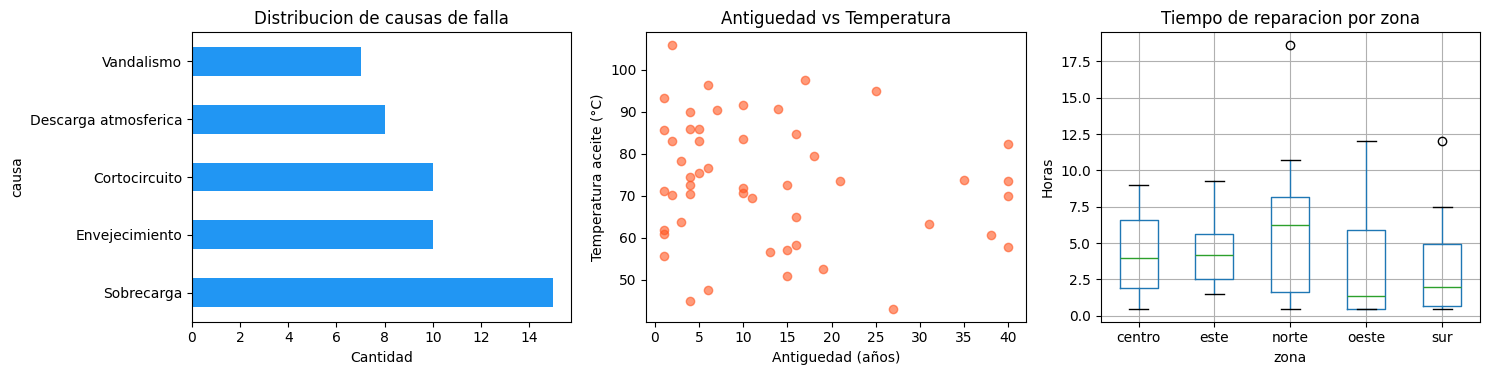


Estadisticas:
       antiguedad_años  carga_pct_promedio  temperatura_aceite_C  \
count             50.0                50.0                  50.0   
mean              12.9                79.4                  73.4   
std               12.1                19.6                  14.8   
min                1.0                46.2                  43.2   
25%                4.0                65.0                  62.3   
50%               10.0                78.2                  73.0   
75%               16.8                93.5                  84.5   
max               40.0               129.7                 105.8   

       tiempo_reparacion_h  
count                 50.0  
mean                   4.4  
std                    4.0  
min                    0.5  
25%                    1.3  
50%                    3.1  
75%                    6.7  
max                   18.6  


In [24]:
# Analisis rapido del dataset sintetico
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribucion de causas
fallas['causa'].value_counts().plot(kind='barh', ax=axes[0], color='#2196F3')
axes[0].set_title('Distribucion de causas de falla')
axes[0].set_xlabel('Cantidad')

# Antiguedad vs temperatura de aceite
axes[1].scatter(fallas['antiguedad_años'], fallas['temperatura_aceite_C'], 
                alpha=0.6, c='#FF5722')
axes[1].set_xlabel('Antiguedad (años)')
axes[1].set_ylabel('Temperatura aceite (°C)')
axes[1].set_title('Antiguedad vs Temperatura')

# Tiempo de reparacion por zona
fallas.boxplot(column='tiempo_reparacion_h', by='zona', ax=axes[2])
axes[2].set_title('Tiempo de reparacion por zona')
axes[2].set_ylabel('Horas')
plt.suptitle('')  # Quitar titulo automatico

plt.tight_layout()
plt.show()

print("\nEstadisticas:")
print(fallas[['antiguedad_años', 'carga_pct_promedio', 'temperatura_aceite_C', 
              'tiempo_reparacion_h']].describe().round(1))

> **¿Qué nos dice este gráfico?** A la izquierda, la distribución de causas de falla sigue las probabilidades que definimos — sobrecarga y envejecimiento son las más frecuentes. En el centro, la relación entre antigüedad y temperatura del aceite no muestra una correlación clara (en datos reales, transformadores más viejos tienden a operar a mayor temperatura). A la derecha, los boxplots muestran que el tiempo de reparación es similar entre zonas, con algunos valores atípicos altos.

### ¿Para qué sirven los datos sintéticos?

| Uso | Ejemplo en EPEC |
|-----|----------------|
| Entrenar modelos con pocas muestras | Predecir fallas con solo 50 casos reales |
| Testing de sistemas | Probar el sistema de reclamos con 10,000 reclamos simulados |
| Análisis what-if | Qué pasa si duplicamos la cantidad de clientes industriales? |
| Privacidad | Compartir datos con proveedores sin exponer datos reales |

> **Cuidado:** Los datos sintéticos NO reemplazan datos reales.  
> Son útiles para empezar, pero siempre deben válidarse contra la realidad.

### 5.2 Riesgos y limitaciones de la IA Generativa

Antes de implementar GenAI en EPEC, es crítico entender los riesgos:

#### Riesgo 1: Alucinaciones

Los LLMs pueden **inventar información que suena convincente pero es falsa**.

```
Pregunta: "Cuál es la tensión nominal del transformador T-4521?"
Respuesta del LLM (sin RAG): "El transformador T-4521 opera a 13.2/0.4 kV 
con una capacidad de 315 kVA, instalado en 2018."

Problema: El LLM invento TODOS esos datos. Suenan razonables pero son falsos.
```

**Mitigación:**
- Usar RAG (que busca en documentos reales)
- Pedir al LLM que cite las fuentes
- SIEMPRE verificar datos críticos (tensiones, procedimientos de seguridad)

#### Riesgo 2: Privacidad y datos sensibles

```
NO ENVIAR a un LLM público (ChatGPT web, Gemini web, etc.):
- Datos personales de clientes (NIS, direcciones, deudas)
- Información de infraestructura crítica
- Datos financieros internos
- Credenciales o passwords
```

**Opciones para usar LLMs con datos sensibles:**

| Opción | Privacidad | Dónde se procesan los datos | Costo | Complejidad |
|--------|-----------|---------------------------|-------|-------------|
| API con acuerdo de no-retención | Media | Servidores del proveedor (OpenAI, Anthropic, etc.) | Medio | Baja |
| Despliegue en nube privada (Azure OpenAI, AWS Bedrock) | Alta | Tu propio entorno cloud, con red aislada | Medio-Alto | Media |
| Modelo local (Llama, Mistral) | Máxima | Tu propio hardware, nada sale de la red | Alto (GPU) | Alta |

**¿Por qué la API tiene privacidad "Media"?** Porque los datos salen de tu red y se procesan en servidores ajenos. El proveedor se compromete contractualmente a no retenerlos ni usarlos para entrenar, pero la garantía es legal (un contrato), no técnica. En los otros dos casos, los datos nunca salen de tu infraestructura — la garantía es técnica.

#### Riesgo 3: Sesgo y equidad

Los LLMs heredan sesgos de sus datos de entrenamiento.

Ejemplo: si un clasificador de reclamos aprende que "barrio X" siempre tiene reclamos de fraude,  
podría sesgar la priorización de reclamos de esa zona.

**Mitigación:**
- Monitorear métricas por grupo (zona, categoría de cliente)
- Auditar decisiones periódicamente
- Mantener un humano en el loop para decisiones que afectan al cliente

#### El principio Human-in-the-Loop

```
                    ┌─────────────┐
   Input ──────>   │   Modelo IA  │ ──────> Sugerencia
                    └─────────────┘            │
                                               v
                                        ┌─────────────┐
                                        │   Humano     │ ──> Decision final
                                        │   revisa     │
                                        └─────────────┘
```

**Regla de oro para EPEC:**
- La IA **sugiere**, el humano **decide**
- Para operaciones criticas (reconexión, corte por fraude): SIEMPRE requiere aprobacion humana
- Para tareas de bajo riesgo (clasificar reclamos, generar reportes): puede ser más automático

### Para seguir explorando: Riesgos de GenAI

**1. Detectar alucinaciones:**
Si tienen acceso a un LLM (ChatGPT, Gemini, etc.), pregúntenle algo muy específico sobre un procedimiento técnico de su empresa. ¿La respuesta es correcta o inventó datos? ¿Cómo lo verificarían?

**2. Clasificar datos por sensibilidad:**
Hagan una lista de 5 tipos de datos que manejan en su trabajo. Para cada uno, clasifíquenlo en: "se puede enviar a un LLM público", "solo LLM privado", "nunca enviar a un LLM".

**3. Diseñar el human-in-the-loop:**
Elijan un caso de uso de IA de los que vimos (clasificación de reclamos, generación de SQL, extracción de datos). Diseñen cómo sería el flujo con un humano en el loop: ¿quién revisa? ¿Cada cuánto? ¿Qué pasa si el modelo se equivoca?

---
## Conclusión del Módulo 4

**Lo que aprendimos hoy:**

1. **LLMs** predicen texto, no "piensan". Tokenización y temperatura son conceptos clave.
2. **Embeddings** convierten texto en números, permitiendo búsqueda por significado — pero no son perfectos.
3. **RAG** conecta LLMs con documentos propios, reduciendo alucinaciones. En producción se complejiza con chunking, búsqueda híbrida, expansión de queries y re-ranking.
4. **Copilotos** asisten en tareas (SQL, Python, extracción de datos) pero el humano siempre revisa.
5. **Datos sintéticos** ayudan cuando hay pocos datos reales.
6. **Riesgos:** alucinaciones, privacidad, sesgo. Siempre human-in-the-loop.

---
## Cierre del Workshop

### Resumen de los 4 módulos

| Módulo | Tema | Herramientas clave |
|--------|------|--------------------|
| 1 | Fundamentos | Regresión, Feature Engineering, Árbol de Decisión |
| 2 | Clasificación + Clustering | Regresión Logística, K-Means, PCA, CRISP-DM |
| 3 | Modelos avanzados | Random Forest, XGBoost, LSTM, Q-Learning |
| 4 | IA Generativa | Embeddings, RAG, Copilotos, Riesgos de GenAI |

### Template: Diseño de piloto de IA para EPEC

Usen esta plantilla para proponer un piloto en su área:

```
PROPUESTA DE PILOTO DE IA
========================

1. PROBLEMA: [Qué problema queremos resolver?]
   Ejemplo: "Tarda 2 horas clasificar manualmente los 200 reclamos diarios"

2. DATOS DISPONIBLES: [Qué datos tenemos hoy?]
   - Fuente: [Sistema, BD, archivos]
   - Volumen: [Cuántos registros? Desde cuando?]
   - Calidad: [Estan limpios? Faltan datos?]

3. ENFOQUE PROPUESTO: [Qué tipo de IA usaríamos?]
   [ ] Regresión (predecir un número)
   [ ] Clasificación (predecir una categoría)
   [ ] Clustering (agrupar sin etiquetas)
   [ ] RAG (consultar documentos con LLM)
   [ ] Copiloto (asistir una tarea específica)

4. METRICA DE EXITO: [Cómo medimos si funciona?]
   Ejemplo: "Reducir tiempo de clasificación de 2h a 15min con >90% accuracy"

5. RIESGOS: [Qué puede salir mal?]
   - Tecnico: [Datos insuficientes? Modelo impreciso?]
   - Organizacional: [Resistencia al cambio? Falta de sponsor?]
   - Etico: [Sesgo? Privacidad?]

6. EQUIPO NECESARIO: [Quien se necesita?]
   - Sponsor de negocio: [Nombre]
   - Datos: [Quien tiene acceso a los datos?]
   - Desarrollo: [Interno o proveedor?]

7. TIMELINE: 
   - Semana 1-2: Explorar datos
   - Semana 3-4: Primer modelo (MVP)
   - Semana 5-6: Validar con usuarios
   - Semana 7-8: Ajustar y documentar
```

### Recursos recomendados

**Para seguir aprendiendo:**

| Recurso | Tipo | Nivel | Link |
|---------|------|-------|------|
| Google AI Studio | Herramienta | Principiante | aistudio.google.com |
| Kaggle Learn | Cursos gratis | Principiante | kaggle.com/learn |
| FastAI | Curso online | Intermedio | fast.ai |
| Hugging Face | Modelos y datasets | Intermedio | huggingface.co |

**Herramientas para empezar rápido:**

| Herramienta | Para qué sirve |
|-------------|---------------|
| Google Colab | Notebooks Python (lo que usamos en el workshop) |
| Google AI Studio | Probar LLMs sin código |
| LangChain | Framework para aplicaciones con LLMs |

---

**Mensaje final:**

> La IA no va a reemplazar a los equipos de IT y operaciones.
> Pero los equipos que **sepan usar IA** van a ser mucho más productivos
> que los que no.
>
> El primer paso no es implementar un proyecto gigante.
> Es elegir **un problema concreto**, probar con datos reales, y aprender haciendo.

**Gracias por participar en el Workshop!**